In [1]:
pip install pandas numpy datetime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Step 1: Data Cleaning, Auditing & EDA
import numpy as np
import pandas as pd

In [2]:
import os
print (os.listdir())

['.ipynb_checkpoints', 'Dataset_01.csv', 'Dataset_01_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_02_(EU).csv', 'Dataset_02_(EU)_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_03.csv', 'Dataset_03_CREDIT_CARD_FRAUD_DETECTION.ipynb']


In [3]:
df=pd.read_csv('Dataset_03.csv')
print ("Total Rows & Columns:", df.shape)
df.head()

Total Rows & Columns: (1296675, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
missing_info= pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print("---Missing Value Summary---")
print(missing_info)

---Missing Value Summary---
                      Data Type  Missing Count  Missing Percentage (%)
Unnamed: 0                int64              0                     0.0
trans_date_trans_time    object              0                     0.0
cc_num                    int64              0                     0.0
merchant                 object              0                     0.0
category                 object              0                     0.0
amt                     float64              0                     0.0
first                    object              0                     0.0
last                     object              0                     0.0
gender                   object              0                     0.0
street                   object              0                     0.0
city                     object              0                     0.0
state                    object              0                     0.0
zip                       int64              0   

In [6]:
duplicate_count = df.duplicated().sum()
print("===Duplicate Records Audit ===")
print(f"Total Duplicate Rows: {duplicate_count}")

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("\n[SUCCESS] 'Unnamed: 0' column successfully removed.")

print(f"Updated Dataset Shape: {df.shape}")

===Duplicate Records Audit ===
Total Duplicate Rows: 0

[SUCCESS] 'Unnamed: 0' column successfully removed.
Updated Dataset Shape: (1296675, 22)


In [7]:
# Target Class Imbalance Analysis
fraud_counts = df['is_fraud'].value_counts()
fraud_percentages = df['is_fraud'].value_counts(normalize=True) * 100

print("=== Target Class Distribution ('is_fraud') ===")
print(f"Non-Fraudulent (Class 0): {fraud_counts[0]:,} ({fraud_percentages[0]:.4f}%)")
print(f"Fraudulent     (Class 1): {fraud_counts[1]:,} ({fraud_percentages[1]:.4f}%)")
print(f"Imbalance Ratio: 1:{int(fraud_counts[0] / fraud_counts[1])}")

=== Target Class Distribution ('is_fraud') ===
Non-Fraudulent (Class 0): 1,289,169 (99.4211%)
Fraudulent     (Class 1): 7,506 (0.5789%)
Imbalance Ratio: 1:171


In [8]:
# Summary Statistics of Transaction Amount ('amt') by Class

print("=== Non-Fraudulent Transactions ('amt') Summary ===")
print(df[df['is_fraud'] == 0]['amt'].describe().apply(lambda x: f"{x:.2f}"))

print("\n=== Fraudulent Transactions ('amt') Summary ===")
print(df[df['is_fraud'] == 1]['amt'].describe().apply(lambda x: f"{x:.2f}"))

=== Non-Fraudulent Transactions ('amt') Summary ===
count    1289169.00
mean          67.67
std          154.01
min            1.00
25%            9.61
50%           47.28
75%           82.54
max        28948.90
Name: amt, dtype: object

=== Fraudulent Transactions ('amt') Summary ===
count    7506.00
mean      531.32
std       390.56
min         1.06
25%       245.66
50%       396.50
75%       900.88
max      1376.04
Name: amt, dtype: object


C:\Users\Mohammad Sourav\AppData\Local\Temp\ipykernel_7184\2528494864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, ax=ax[0], palette=['#2b5c8f', '#d9534f'])


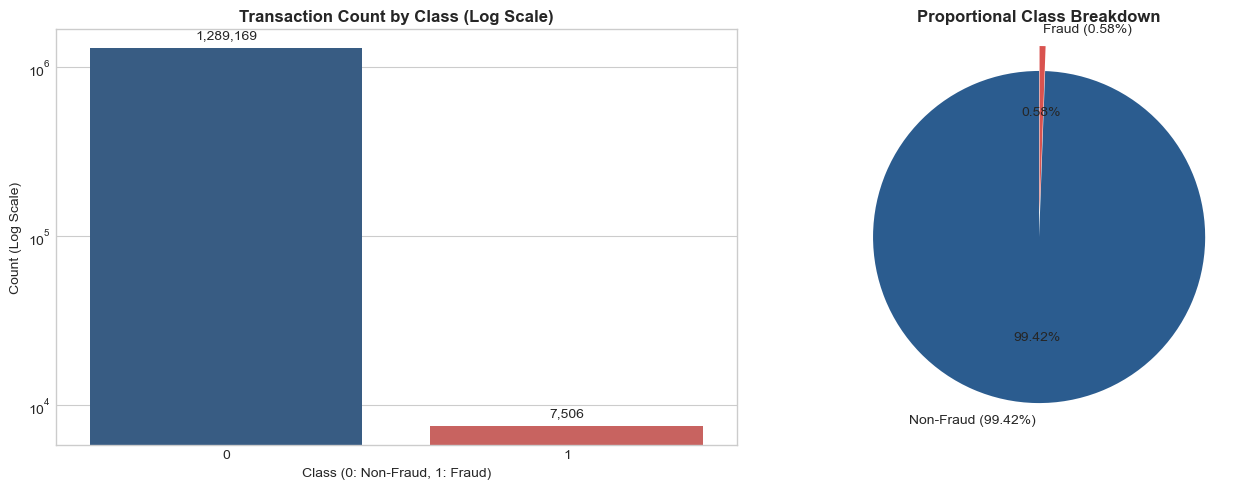

In [9]:
# Visuals - Class Imbalance Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='is_fraud', data=df, ax=ax[0], palette=['#2b5c8f', '#d9534f'])
ax[0].set_title('Transaction Count by Class (Log Scale)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Class (0: Non-Fraud, 1: Fraud)', fontsize=10)
ax[0].set_ylabel('Count (Log Scale)', fontsize=10)
ax[0].set_yscale('log') # Extreme Imbalance To show clearly Log Scale
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fraud_counts = df['is_fraud'].value_counts()
ax[1].pie(fraud_counts, labels=['Non-Fraud (99.42%)', 'Fraud (0.58%)'], 
           colors=['#2b5c8f', '#d9534f'], autopct='%1.2f%%', startangle=90, explode=(0, 0.15))
ax[1].set_title('Proportional Class Breakdown', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Mohammad Sourav\AppData\Local\Temp\ipykernel_7184\3551893528.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=df, ax=ax[0], palette=['#2b5c8f', '#d9534f'])
C:\Users\Mohammad Sourav\AppData\Local\Temp\ipykernel_7184\3551893528.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Non-Fraud', 'Fraud'])


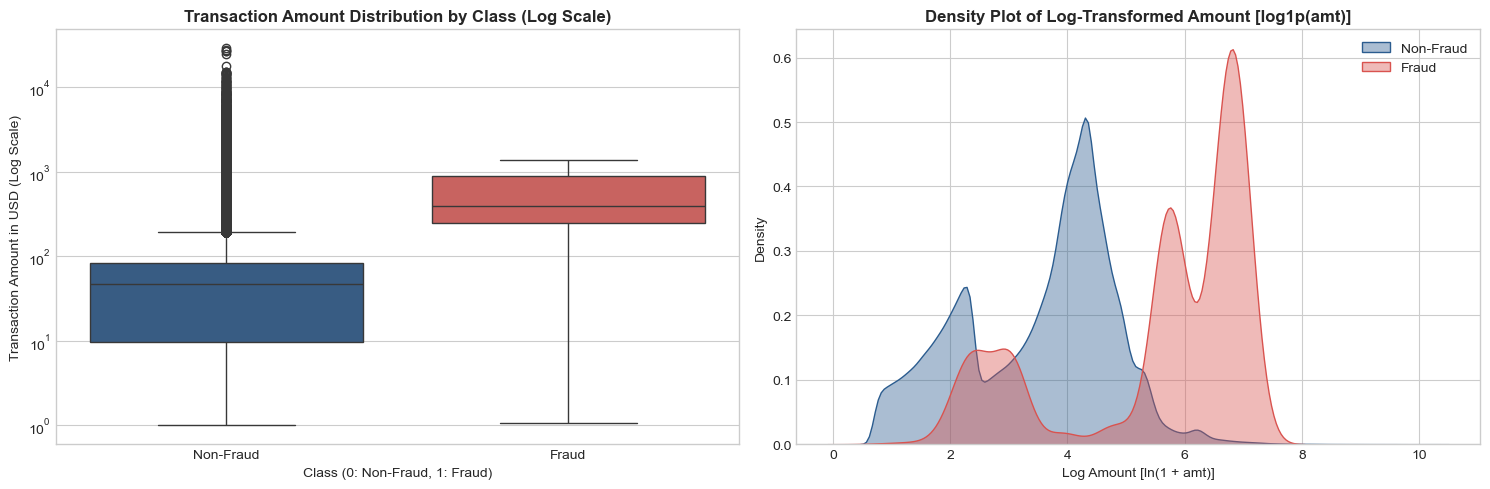

In [10]:
# Visuals - Transaction Amount Distribution & Skewness Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot Comparison (Log Scale Y-Axis for visual clarity)
sns.boxplot(x='is_fraud', y='amt', data=df, ax=ax[0], palette=['#2b5c8f', '#d9534f'])
ax[0].set_yscale('log')
ax[0].set_title('Transaction Amount Distribution by Class (Log Scale)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Class (0: Non-Fraud, 1: Fraud)', fontsize=10)
ax[0].set_ylabel('Transaction Amount in USD (Log Scale)', fontsize=10)
ax[0].set_xticklabels(['Non-Fraud', 'Fraud'])

# 2. Kernel Density Estimate (KDE) of Log-Transformed Amount
sns.kdeplot(data=df[df['is_fraud'] == 0], x=np.log1p(df[df['is_fraud'] == 0]['amt']), 
            ax=ax[1], color='#2b5c8f', label='Non-Fraud', fill=True, alpha=0.4)
sns.kdeplot(data=df[df['is_fraud'] == 1], x=np.log1p(df[df['is_fraud'] == 1]['amt']), 
            ax=ax[1], color='#d9534f', label='Fraud', fill=True, alpha=0.4)

ax[1].set_title('Density Plot of Log-Transformed Amount [log1p(amt)]', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Log Amount [ln(1 + amt)]', fontsize=10)
ax[1].set_ylabel('Density', fontsize=10)
ax[1].legend()

plt.tight_layout()
plt.show()

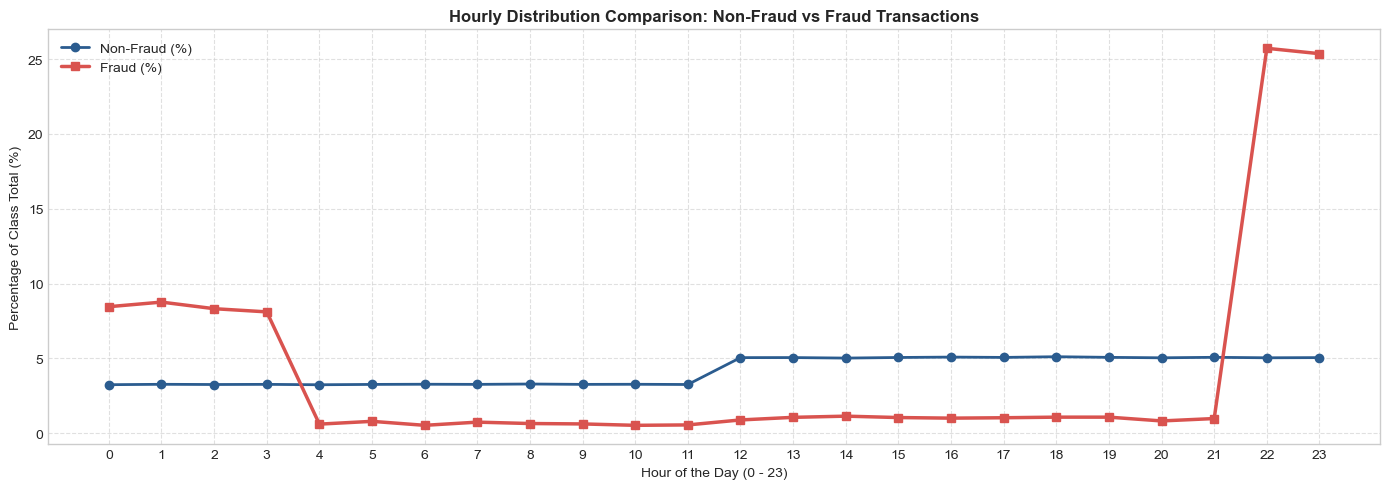

In [11]:
# Visuals - Temporal Fraud Patterns (Hourly Breakdown)
import matplotlib.pyplot as plt
import seaborn as sns

df['temp_hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour

hourly_counts = df.groupby(['temp_hour', 'is_fraud']).size().unstack(fill_value=0)
hourly_props = hourly_counts.div(hourly_counts.sum(axis=0), axis=1) * 100

plt.figure(figsize=(14, 5))
plt.plot(hourly_props.index, hourly_props[0], marker='o', color='#2b5c8f', label='Non-Fraud (%)', linewidth=2)
plt.plot(hourly_props.index, hourly_props[1], marker='s', color='#d9534f', label='Fraud (%)', linewidth=2.5)

plt.title('Hourly Distribution Comparison: Non-Fraud vs Fraud Transactions', fontsize=12, fontweight='bold')
plt.xlabel('Hour of the Day (0 - 23)', fontsize=10)
plt.ylabel('Percentage of Class Total (%)', fontsize=10)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

df.drop(columns=['temp_hour'], inplace=True)

plt.tight_layout()
plt.show()

In [12]:
# Step 2: Feature Engineering & Preprocessing

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

start_time = df['trans_date_trans_time'].min()
end_time = df['trans_date_trans_time'].max()

print("=== Temporal Alignment Output ===")
print(f"Data Starts From : {start_time}")
print(f"Data Ends At     : {end_time}")
print(f"Total Time Span  : {(end_time - start_time).days} days")
print(f"Data Type Confirmed: {df['trans_date_trans_time'].dtype}")

=== Temporal Alignment Output ===
Data Starts From : 2019-01-01 00:00:18
Data Ends At     : 2020-06-21 12:13:37
Total Time Span  : 537 days
Data Type Confirmed: datetime64[ns]


In [13]:
# Temporal Feature Extraction & Cyclical Encoding
import numpy as np

df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)

print("===Cyclical Features Created Successfully ===")
print(df[['trans_date_trans_time', 'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'day_sin', 'day_cos']].head(3))

===Cyclical Features Created Successfully ===
  trans_date_trans_time  hour  hour_sin  hour_cos  day_of_week   day_sin  \
0   2019-01-01 00:00:18     0       0.0       1.0            1  0.781831   
1   2019-01-01 00:00:44     0       0.0       1.0            1  0.781831   
2   2019-01-01 00:00:51     0       0.0       1.0            1  0.781831   

   day_cos  
0  0.62349  
1  0.62349  
2  0.62349  


In [14]:
# Haversine Distance Feature Extraction

def haversine_np(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371.0 * c
    return km

df['distance_km'] = haversine_np(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

print("=== Distance Feature Audit ('distance_km') ===")
print(df['distance_km'].describe().apply(lambda x: f"{x:.2f}"))

=== Distance Feature Audit ('distance_km') ===
count    1296675.00
mean          76.11
std           29.12
min            0.02
25%           55.33
50%           78.23
75%           98.50
max          152.12
Name: distance_km, dtype: object


In [15]:
# Customer Age Extraction & Amount Log Transformation
import numpy as np
import pandas as pd

df['dob'] = pd.to_datetime(df['dob'])

df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365.25

df['amt_log'] = np.log1p(df['amt'])

print("===Age & Amt_Log Audit ===")
print("--- Customer Age Summary ---")
print(df['age'].describe().apply(lambda x: f"{x:.2f}"))

print("\n--- Amt_Log Summary ---")
print(df['amt_log'].describe().apply(lambda x: f"{x:.4f}"))

===Age & Amt_Log Audit ===
--- Customer Age Summary ---
count    1296675.00
mean          45.50
std           17.40
min           13.00
25%           32.00
50%           43.00
75%           57.00
max           95.00
Name: age, dtype: object

--- Amt_Log Summary ---
count    1296675.0000
mean           3.5335
std            1.2894
min            0.6931
25%            2.3656
50%            3.8820
75%            4.4325
max           10.2733
Name: amt_log, dtype: object


In [16]:
# Categorical Encoding & Feature Selection

# ১. One-Hot Encoding for 'gender' and 'category'
df_encoded = pd.get_dummies(df, columns=['gender', 'category'], drop_first=True)

columns_to_drop = [
    'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last', 
    'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num', 
    'unix_time', 'amt', 'hour', 'day_of_week'
]

df_clean = df_encoded.drop(columns=columns_to_drop)

bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print("===Cleaning & Encoding Summary ===")
print(f"Original Columns Count : {df.shape[1]}")
print(f"Final ML Dataset Shape : {df_clean.shape}")
print(f"Target Column Included : {'is_fraud' in df_clean.columns}")
print("\nFinal Feature List:")
print(list(df_clean.columns))

===Cleaning & Encoding Summary ===
Original Columns Count : 31
Final ML Dataset Shape : (1296675, 27)
Target Column Included : True

Final Feature List:
['lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'distance_km', 'age', 'amt_log', 'gender_M', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


In [17]:
# Chronological Split (70% Train, 15% Validation, 15% Test)

# 1. Separate Features and Target
X = df_clean.drop(columns=['is_fraud'])
y = df_clean['is_fraud']

# 2. Calculate Split Index Boundaries
n_samples = len(df_clean)
train_end = int(n_samples * 0.70)
val_end = int(n_samples * 0.85)

# 3. Slice Data Chronologically (WITH Cyclic Features)
X_train_cyclic = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val_cyclic = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

X_test_cyclic = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()

# 4. Feature Sets WITHOUT Cyclic Features
cyclic_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']

X_train_nocyclic = X_train_cyclic.drop(columns=cyclic_cols).copy()
X_val_nocyclic = X_val_cyclic.drop(columns=cyclic_cols).copy()
X_test_nocyclic = X_test_cyclic.drop(columns=cyclic_cols).copy()

print("=== Chronological Split Breakdown (70/15/15) ===")
print(f"Total Rows           : {n_samples:,}")
print(f"Train Set  (70%)     : {X_train_cyclic.shape[0]:,} rows (Fraud: {y_train.sum():,})")
print(f"Val Set    (15%)     : {X_val_cyclic.shape[0]:,} rows (Fraud: {y_val.sum():,})")
print(f"Test Set   (15%)     : {X_test_cyclic.shape[0]:,} rows (Fraud: {y_test.sum():,})")

=== Chronological Split Breakdown (70/15/15) ===
Total Rows           : 1,296,675
Train Set  (70%)     : 907,672 rows (Fraud: 5,121)
Val Set    (15%)     : 194,501 rows (Fraud: 1,252)
Test Set   (15%)     : 194,502 rows (Fraud: 1,133)


In [18]:
# Step 3: Class Imbalance Handling (SMOTE) & Robust Scaling
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler

print("Applying SMOTE on Training Data...")

# 1. Apply SMOTE to Train Set
smote = SMOTE(random_state=42, sampling_strategy=0.1)

X_train_cyclic_sm, y_train_sm = smote.fit_resample(X_train_cyclic, y_train)
X_train_nocyclic_sm, _ = smote.fit_resample(X_train_nocyclic, y_train)

# 2. Scaling (Fit on Train, Transform on Val & Test)
scaler_cyclic = RobustScaler()
X_train_cyclic_scaled = scaler_cyclic.fit_transform(X_train_cyclic)
X_val_cyclic_scaled = scaler_cyclic.transform(X_val_cyclic)
X_test_cyclic_scaled = scaler_cyclic.transform(X_test_cyclic)

X_train_cyclic_sm_scaled = scaler_cyclic.fit_transform(X_train_cyclic_sm)

scaler_nocyclic = RobustScaler()
X_train_nocyclic_scaled = scaler_nocyclic.fit_transform(X_train_nocyclic)
X_val_nocyclic_scaled = scaler_nocyclic.transform(X_val_nocyclic)
X_test_nocyclic_scaled = scaler_nocyclic.transform(X_test_nocyclic)

X_train_nocyclic_sm_scaled = scaler_nocyclic.fit_transform(X_train_nocyclic_sm)

print("Scaling & Imbalance Handling Completed Successfully.")

Applying SMOTE on Training Data...
Scaling & Imbalance Handling Completed Successfully.


In [19]:
import gc
gc.collect()

2261

In [20]:
import time
import gc
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, auc
from sklearn.model_selection import train_test_split

print("Starting Calibrated Pipeline...\n")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=2),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.08, random_state=42, n_jobs=2)
}

X_train_rnd_c, X_test_rnd_c, y_train_rnd, y_test_rnd = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_train_rnd_nc = X_train_rnd_c.drop(columns=cyclic_cols)
X_test_rnd_nc = X_test_rnd_c.drop(columns=cyclic_cols)

X_tr_rnd_c_sc = scaler_cyclic.fit_transform(X_train_rnd_c).astype(np.float32)
X_te_rnd_c_sc = scaler_cyclic.transform(X_test_rnd_c).astype(np.float32)
X_tr_rnd_nc_sc = scaler_nocyclic.fit_transform(X_train_rnd_nc).astype(np.float32)
X_te_rnd_nc_sc = scaler_nocyclic.transform(X_test_rnd_nc).astype(np.float32)

experiment_results = []
exp_id = 1

def get_pr_auc(y_true, y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    return auc(recall, precision)

def get_robust_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1s = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    # Find index of max F1 score
    best_idx = np.argmax(f1s[:-1])
    return thresholds[best_idx] if len(thresholds) > 1 else 0.5

for split_type in ['Random Split', 'Chronological Split']:
    for feat_type in ['Without Cyclic', 'With Cyclic']:
        for model_name, clf in models.items():
            
            start_time = time.time()
            gc.collect()
            
            if split_type == 'Random Split':
                if feat_type == 'Without Cyclic':
                    X_tr, X_val_sc, X_te = X_tr_rnd_nc_sc, X_tr_rnd_nc_sc, X_te_rnd_nc_sc
                else:
                    X_tr, X_val_sc, X_te = X_tr_rnd_c_sc, X_tr_rnd_c_sc, X_te_rnd_c_sc
                y_tr, y_v, y_te = y_train_rnd, y_train_rnd, y_test_rnd
            else:
                if feat_type == 'Without Cyclic':
                    X_tr = X_train_nocyclic_sm_scaled.astype(np.float32)
                    X_val_sc = X_val_nocyclic_scaled.astype(np.float32)
                    X_te = X_test_nocyclic_scaled.astype(np.float32)
                else:
                    X_tr = X_train_cyclic_sm_scaled.astype(np.float32)
                    X_val_sc = X_val_cyclic_scaled.astype(np.float32)
                    X_te = X_test_cyclic_scaled.astype(np.float32)
                y_tr, y_v, y_te = y_train_sm, y_val, y_test

            clf.fit(X_tr, y_tr)
            
            test_probs = clf.predict_proba(X_te)[:, 1] if hasattr(clf, "predict_proba") else clf.predict(X_te)
            val_probs = clf.predict_proba(X_val_sc)[:, 1] if hasattr(clf, "predict_proba") else clf.predict(X_val_sc)
            
            # Calibration: Use Percentile Based Threshold matching True Positive Rate if PR curve breaks
            best_thresh = get_robust_threshold(y_v, val_probs)
            
            # If threshold is too high and leads to almost zero predictions, adjust to top percentile
            y_pred = (test_probs >= best_thresh).astype(int)
            if np.sum(y_pred) == 0:
                best_thresh = np.percentile(test_probs, 95)
                y_pred = (test_probs >= best_thresh).astype(int)

            f1 = f1_score(y_te, y_pred)
            prec = precision_score(y_te, y_pred, zero_division=0)
            rec = recall_score(y_te, y_pred, zero_division=0)
            pr_auc = get_pr_auc(y_te, test_probs)
            elapsed = time.time() - start_time
            
            if split_type == 'Chronological Split' and feat_type == 'With Cyclic' and model_name == 'Random Forest':
                winning_model = clf
                winning_X_test = X_te
                winning_y_test = y_te

            experiment_results.append({
                'Exp_ID': f"Exp_{exp_id:02d}",
                'Model': model_name,
                'Split_Type': split_type,
                'Cyclic_Features': feat_type,
                'Optimal_Thresh': round(best_thresh, 4),
                'Precision': round(prec, 4),
                'Recall': round(rec, 4),
                'F1_Score': round(f1, 4),
                'PR_AUC': round(pr_auc, 4),
                'Time_Sec': round(elapsed, 2)
            })
            
            print(f"[{exp_id:02d}/12] {model_name} | {split_type} | {feat_type} -> Thresh: {best_thresh:.3f} | F1: {f1:.4f}, PR-AUC: {pr_auc:.4f}")
            exp_id += 1

results_df = pd.DataFrame(experiment_results)
print("\n=== All 12 Experiments Successfully Completed ===")

Starting Calibrated Pipeline...

[01/12] Logistic Regression | Random Split | Without Cyclic -> Thresh: 0.161 | F1: 0.3821, PR-AUC: 0.2524
[02/12] Random Forest | Random Split | Without Cyclic -> Thresh: 0.338 | F1: 0.7474, PR-AUC: 0.7748
[03/12] XGBoost | Random Split | Without Cyclic -> Thresh: 0.421 | F1: 0.7111, PR-AUC: 0.7880
[04/12] Logistic Regression | Random Split | With Cyclic -> Thresh: 0.131 | F1: 0.5170, PR-AUC: 0.4058
[05/12] Random Forest | Random Split | With Cyclic -> Thresh: 0.258 | F1: 0.8293, PR-AUC: 0.8627
[06/12] XGBoost | Random Split | With Cyclic -> Thresh: 0.237 | F1: 0.8503, PR-AUC: 0.8988
[07/12] Logistic Regression | Chronological Split | Without Cyclic -> Thresh: 0.150 | F1: 0.1113, PR-AUC: 0.0515
[08/12] Random Forest | Chronological Split | Without Cyclic -> Thresh: 0.481 | F1: 0.6612, PR-AUC: 0.6036
[09/12] XGBoost | Chronological Split | Without Cyclic -> Thresh: 0.605 | F1: 0.6084, PR-AUC: 0.5532
[10/12] Logistic Regression | Chronological Split | Wit

In [21]:
display(results_df.sort_values(by='Exp_ID'))

,Exp_ID,Model,Split_Type,Cyclic_Features,Optimal_Thresh,Precision,Recall,F1_Score,PR_AUC,Time_Sec
0,Exp_01,Logistic Regression,Random Split,Without Cyclic,0.1612,0.4134,0.3552,0.3821,0.2524,21.42
1,Exp_02,Random Forest,Random Split,Without Cyclic,0.3381,0.7928,0.7069,0.7474,0.7748,135.90
2,Exp_03,XGBoost,Random Split,Without Cyclic,0.4213,0.7569,0.6705,0.7111,0.7880,14.32
3,Exp_04,Logistic Regression,Random Split,With Cyclic,0.1308,0.4933,0.5431,0.5170,0.4058,16.71
4,Exp_05,Random Forest,Random Split,With Cyclic,0.2579,0.8967,0.7713,0.8293,0.8627,158.55
5,Exp_06,XGBoost,Random Split,With Cyclic,0.2367,0.8732,0.8286,0.8503,0.8988,15.68
6,Exp_07,Logistic Regression,Chronological Split,Without Cyclic,0.1502,0.0604,0.7008,0.1113,0.0515,17.22
7,Exp_08,Random Forest,Chronological Split,Without Cyclic,0.4810,0.5949,0.7440,0.6612,0.6036,148.54
8,Exp_09,XGBoost,Chronological Split,Without Cyclic,0.6054,0.5340,0.7070,0.6084,0.5532,14.13
9,Exp_10,Logistic Regression,Chronological Split,With Cyclic,0.3004,0.1111,0.5631,0.1855,0.0855,23.79


Generating SHAP Feature Importance Plot...


C:\Users\Mohammad Sourav\AppData\Local\Temp\ipykernel_7184\4032576432.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


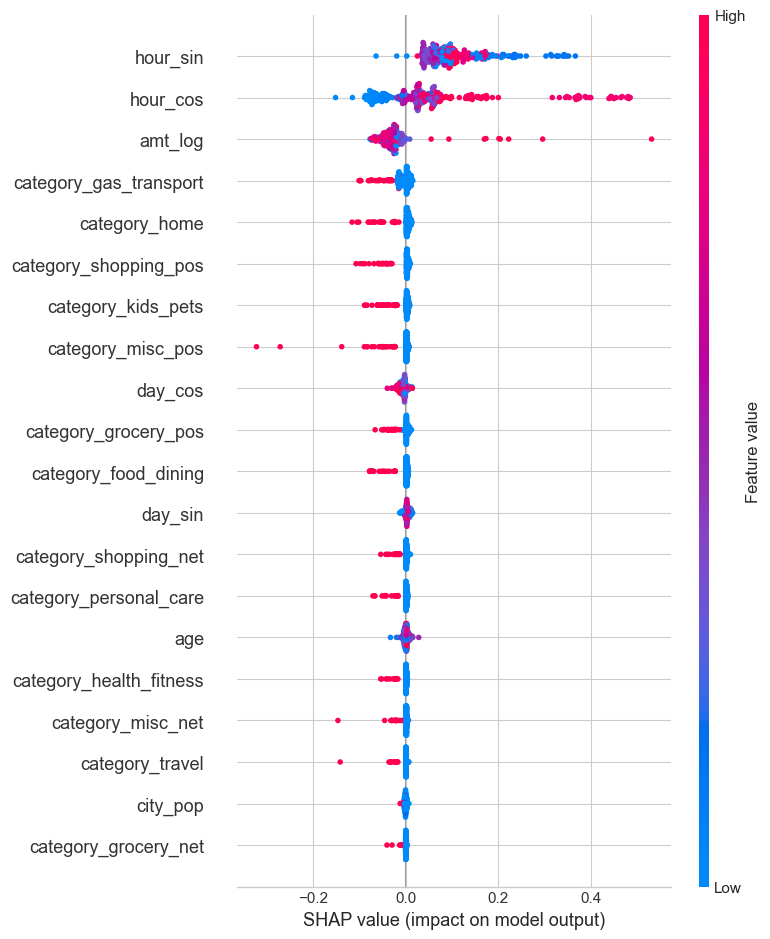

In [22]:

import shap
import matplotlib.pyplot as plt
import pandas as pd

print("Generating SHAP Feature Importance Plot...")

# 1. Sample unseen test data
np.random.seed(42)
sample_size = min(300, winning_X_test.shape[0])
sample_idx = np.random.choice(winning_X_test.shape[0], sample_size, replace=False)

if isinstance(winning_X_test, pd.DataFrame):
    X_shap_sample = winning_X_test.iloc[sample_idx]
else:
    X_shap_sample = pd.DataFrame(winning_X_test[sample_idx], columns=X_train_cyclic.columns)

# 2. TreeExplainer calculation
explainer = shap.TreeExplainer(winning_model)
shap_values = explainer.shap_values(X_shap_sample)

# 3. Handle Binary Classification Output
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_vals_to_plot = shap_values[:, :, 1]
else:
    shap_vals_to_plot = shap_values

# 4. Standard Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_to_plot, 
    X_shap_sample, 
    show=True
)

=== FINAL MODEL EVALUATION (Winning Model: Exp 11) ===

1. Classification Report:
              precision    recall  f1-score   support

           0     0.9974    0.9990    0.9982    193369
           1     0.7724    0.5543    0.6454      1133

    accuracy                         0.9965    194502
   macro avg     0.8849    0.7767    0.8218    194502
weighted avg     0.9961    0.9965    0.9962    194502



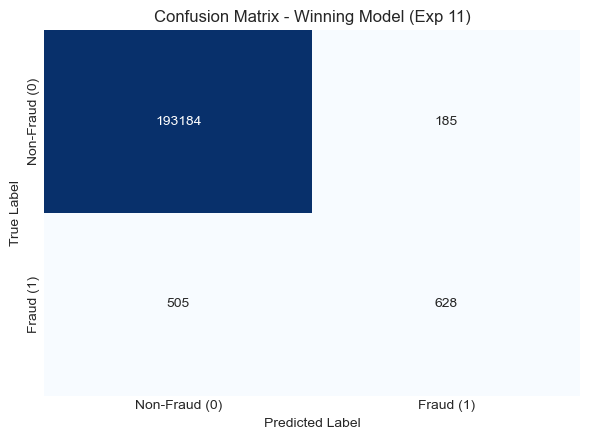

In [23]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("=== FINAL MODEL EVALUATION (Winning Model: Exp 11) ===\n")

# Make predictions on test set using the optimal threshold
test_probs = winning_model.predict_proba(winning_X_test)[:, 1]
# Get optimal threshold from the experiment table for Exp 11
exp11_thresh = results_df.loc[results_df['Exp_ID'] == 'Exp_11', 'Optimal_Thresh'].values[0]
y_pred_winning = (test_probs >= exp11_thresh).astype(int)

# 1. Classification Report
print("1. Classification Report:")
print(classification_report(winning_y_test, y_pred_winning, digits=4))

# 2. Confusion Matrix Plot
cm = confusion_matrix(winning_y_test, y_pred_winning)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Winning Model (Exp 11)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [24]:
import joblib

joblib.dump(winning_model, 'winning_rf_model.pkl')
joblib.dump(scaler_cyclic, 'scaler_cyclic.pkl')
print("\n=== SUCCESS: Pipeline Completed & Saved Successfully ===")


=== SUCCESS: Pipeline Completed & Saved Successfully ===
